# 1.0 Daily Demand Aggregation

- Convert the order-level dataset into a daily time series
- Create the two forecasting base metrics:
  - orders per day
  - revenue per day
- Ensure complete daily date coverage before modeling
- Produce the base dataset used throughout Workbook 11

## 1.1 Load Dataset

- Load the cleaned 2025 full-order dataset
- Parse the datetime field
- Convert the timestamp to America/Los_Angeles

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv('../data/cleaned/orders_2025_full.csv')

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(df.shape)
print()
print(df.columns.tolist())
print()
df.head()

(50487, 9)

['order_date', 'order_id', 'order_type', 'tax_amount', 'tip', 'discount', 'order_total', 'payments_total', 'tender']



,order_date,order_id,order_type,tax_amount,tip,discount,order_total,payments_total,tender
0,2025-03-31 22:54:00-07:00,QQBMWE3NMZQ0Y,Pick Up,2.09,0.00,0.0,25.99,25.99,Cash
1,2025-03-31 22:35:00-07:00,TH041BMRDC2Y6,Delivery,0.00,0.00,0.0,25.13,0.00,NaN
2,2025-03-31 22:33:00-07:00,06KJV691ZMV48,Pick Up,1.44,3.29,0.0,17.90,17.90,Debit Card
3,2025-03-31 22:24:00-07:00,ASKA2CPN7GT2A,Pick Up,3.27,0.00,0.0,40.69,40.69,Cash
4,2025-03-31 22:23:00-07:00,GK5Z5D128NA1M,Pick Up,1.61,0.92,0.0,20.05,20.05,Credit Card


## 1.2 Create Datetime Column

- Convert raw date column into datetime format
- Standardize timezone to America/Los_Angeles

In [6]:
df['order_datetime'] = pd.to_datetime(df['order_date'], utc=True)
df['order_datetime'] = df['order_datetime'].dt.tz_convert('America/Los_Angeles')

df[['order_date', 'order_datetime']].head()

,order_date,order_datetime
0,2025-03-31 22:54:00-07:00,2025-03-31 22:54:00-07:00
1,2025-03-31 22:35:00-07:00,2025-03-31 22:35:00-07:00
2,2025-03-31 22:33:00-07:00,2025-03-31 22:33:00-07:00
3,2025-03-31 22:24:00-07:00,2025-03-31 22:24:00-07:00
4,2025-03-31 22:23:00-07:00,2025-03-31 22:23:00-07:00


## 1.3 Create Daily Date Field

- Extract calendar date from timestamp
- Remove timezone for aggregation consistency

In [7]:
df['order_date_clean'] = df['order_datetime'].dt.floor('D').dt.tz_localize(None)

df[['order_datetime', 'order_date_clean']].head()

,order_datetime,order_date_clean
0,2025-03-31 22:54:00-07:00,2025-03-31
1,2025-03-31 22:35:00-07:00,2025-03-31
2,2025-03-31 22:33:00-07:00,2025-03-31
3,2025-03-31 22:24:00-07:00,2025-03-31
4,2025-03-31 22:23:00-07:00,2025-03-31


## 1.4 Aggregate to Daily Level

- Group dataset by day
- Compute:
  - daily order volume
  - daily revenue

In [8]:
daily = (
    df.groupby('order_date_clean')
      .agg(
          orders=('order_datetime', 'size'),
          revenue=('order_total', 'sum')
      )
      .reset_index()
)

daily.head()

,order_date_clean,orders,revenue
0,2025-01-01,163,5474.36
1,2025-01-02,100,2936.25
2,2025-01-03,165,5314.05
3,2025-01-04,164,5095.98
4,2025-01-05,163,4679.32


## 1.5 Sort Daily Time Series

- Sort dataset chronologically
- Prepare for time series operations

In [10]:
daily = daily.sort_values('order_date_clean').reset_index(drop=True)

daily.head()

,order_date_clean,orders,revenue
0,2025-01-01,163,5474.36
1,2025-01-02,100,2936.25
2,2025-01-03,165,5314.05
3,2025-01-04,164,5095.98
4,2025-01-05,163,4679.32


## 1.6 Check for Missing Dates

- Create full daily calendar across observed range
- Identify gaps in time series

In [11]:
full_date_range = pd.date_range(
    start=daily['order_date_clean'].min(),
    end=daily['order_date_clean'].max(),
    freq='D'
)

missing_dates = full_date_range.difference(daily['order_date_clean'])

print(f'Missing dates: {len(missing_dates)}')
missing_dates[:10]

Missing dates: 2


DatetimeIndex(['2025-04-20', '2025-12-25'], dtype='datetime64[ns]', freq=None)

## 1.7 Reindex to Full Daily Calendar

- Reindex dataset to complete date range
- Fill missing days with 0 orders and 0 revenue

In [12]:
daily = (
    daily.set_index('order_date_clean')
         .reindex(full_date_range, fill_value=0)
         .rename_axis('order_date')
         .reset_index()
)

daily.head()

,order_date,orders,revenue
0,2025-01-01,163,5474.36
1,2025-01-02,100,2936.25
2,2025-01-03,165,5314.05
3,2025-01-04,164,5095.98
4,2025-01-05,163,4679.32


## 1.8 Validate Final Daily Dataset

- Confirm:
  - no null values
  - correct data types
  - continuous daily coverage

In [13]:
daily.info()

daily.isna().sum()

daily.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_date  365 non-null    datetime64[ns]
 1   orders      365 non-null    int64         
 2   revenue     365 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 8.7 KB


,order_date,orders,revenue
count,365,365.000000,365.000000
mean,2025-07-01 23:59:59.999999744,138.320548,4245.909836
min,2025-01-01 00:00:00,0.000000,0.000000
25%,2025-04-02 00:00:00,110.000000,3097.230000
50%,2025-07-02 00:00:00,136.000000,4009.670000
75%,2025-10-01 00:00:00,167.000000,5314.050000
max,2025-12-31 00:00:00,267.000000,9678.900000
std,NaN,37.920373,1405.269892


## 1.9 Preview Final Output

- Inspect beginning and end of dataset
- Confirm readiness for time series analysis

In [14]:
display(daily.head())
display(daily.tail())

,order_date,orders,revenue
0,2025-01-01,163,5474.36
1,2025-01-02,100,2936.25
2,2025-01-03,165,5314.05
3,2025-01-04,164,5095.98
4,2025-01-05,163,4679.32


,order_date,orders,revenue
360,2025-12-27,216,6743.76
361,2025-12-28,211,6171.57
362,2025-12-29,124,3770.69
363,2025-12-30,131,3968.45
364,2025-12-31,233,8654.91


# 2.0 Time Series Exploration

- Analyze daily demand patterns before forecasting
- Visualize order volume and revenue over time
- Identify trend, seasonality, and variability
- Establish baseline understanding of demand behavior

## 2.1 Plot Daily Orders

- Visualize daily order volume over time
- Identify overall trend and volatility

## plt.figure(figsize=(12,6))
plt.plot(daily['order_date'], daily['orders'])

plt.title('Daily Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Orders')

plt.xticks(rotation=45)

plt.show()

## 2.2 Plot Daily Revenue

- Visualize daily revenue over time
- Compare revenue stability vs order volume

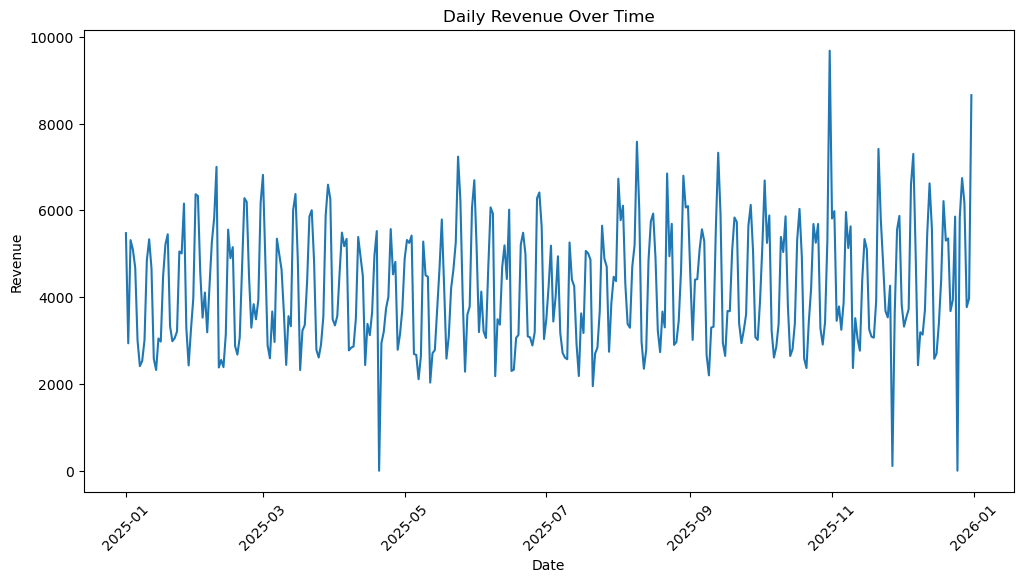

In [16]:
plt.figure(figsize=(12,6))
plt.plot(daily['order_date'], daily['revenue'])

plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

## 2.3 Add 7-Day Rolling Averages

- Smooth daily fluctuations using weekly window
- Create trend-focused signals for orders and revenue

In [17]:
daily['orders_7d_avg'] = daily['orders'].rolling(window=7).mean()
daily['revenue_7d_avg'] = daily['revenue'].rolling(window=7).mean()

daily.head()

,order_date,orders,revenue,orders_7d_avg,revenue_7d_avg
0,2025-01-01,163,5474.36,NaN,NaN
1,2025-01-02,100,2936.25,NaN,NaN
2,2025-01-03,165,5314.05,NaN,NaN
3,2025-01-04,164,5095.98,NaN,NaN
4,2025-01-05,163,4679.32,NaN,NaN


## 2.4 Remove Invalid Zero-Demand Days

- Remove days with zero orders
- Prevent distortion in rolling averages and forecasting
- Ensure clean demand signal for modeling
- Zero-demand days identified as data anomalies and removed prior to modeling

In [23]:
daily = daily[daily['orders'] > 0]

## 2.5 Plot Raw vs Smoothed Demand

- Compare raw daily values vs 7-day rolling average
- Highlight underlying trend direction

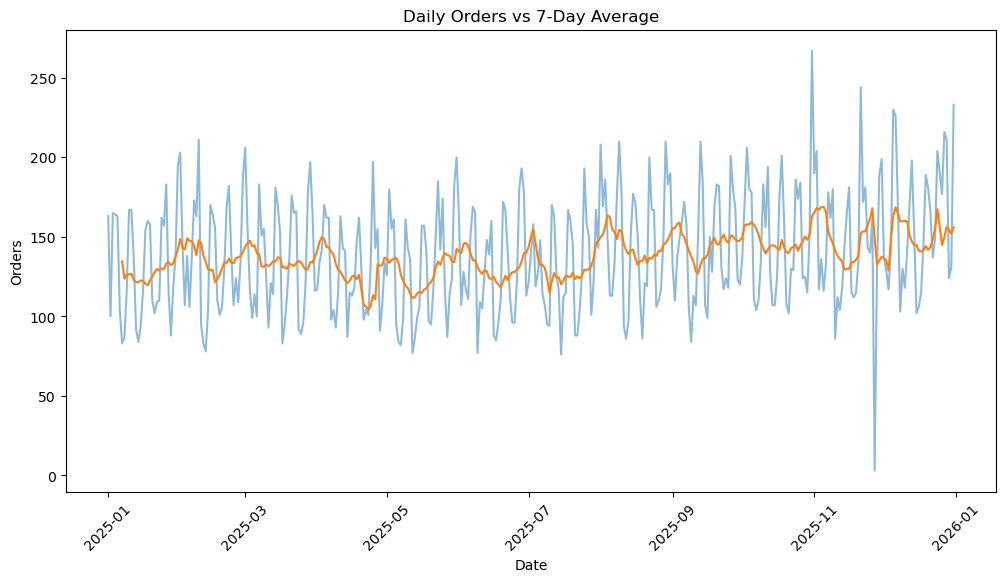

In [24]:
plt.figure(figsize=(12,6))
plt.plot(daily['order_date'], daily['orders'], alpha=0.5)
plt.plot(daily['order_date'], daily['orders_7d_avg'])

plt.title('Daily Orders vs 7-Day Average')
plt.xlabel('Date')
plt.ylabel('Orders')

plt.xticks(rotation=45)

plt.show()

## 2.6 Plot Revenue Trend vs Noise

- Compare raw revenue vs smoothed revenue
- Identify consistency and demand stability

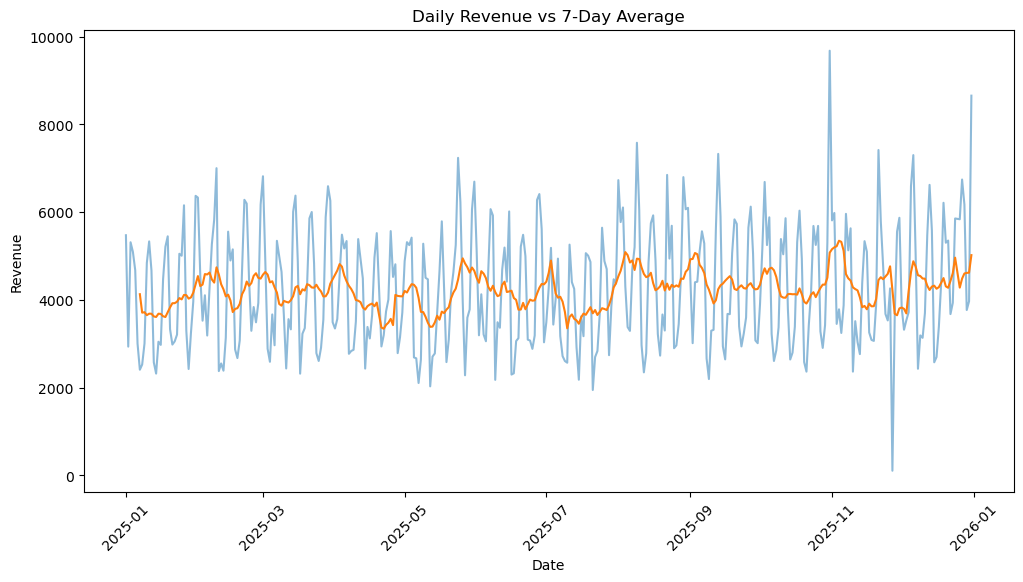

In [25]:
plt.figure(figsize=(12,6))
plt.plot(daily['order_date'], daily['revenue'], alpha=0.5)
plt.plot(daily['order_date'], daily['revenue_7d_avg'])

plt.title('Daily Revenue vs 7-Day Average')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

# 3.0 Forecasting Baseline

- Build a simple, interpretable forecasting baseline
- Use rolling averages to predict short-term demand
- Compare forecasted values against actual daily demand
- Establish a business-usable model before any advanced approach

## 3.1 Create Forecasting Copy

- Create a modeling copy of the cleaned daily dataset
- Preserve the original time series for reference

In [26]:
forecast_df = daily.copy()

forecast_df.head()

,order_date,orders,revenue,orders_7d_avg,revenue_7d_avg
0,2025-01-01,163,5474.36,NaN,NaN
1,2025-01-02,100,2936.25,NaN,NaN
2,2025-01-03,165,5314.05,NaN,NaN
3,2025-01-04,164,5095.98,NaN,NaN
4,2025-01-05,163,4679.32,NaN,NaN


## 3.2 Create Naive Forecast

- Use the previous day’s orders as the baseline forecast
- Establish a simple benchmark for comparison

In [27]:
forecast_df['naive_forecast'] = forecast_df['orders'].shift(1)

forecast_df[['order_date', 'orders', 'naive_forecast']].head()

,order_date,orders,naive_forecast
0,2025-01-01,163,NaN
1,2025-01-02,100,163.0
2,2025-01-03,165,100.0
3,2025-01-04,164,165.0
4,2025-01-05,163,164.0


## 3.3 Create 7-Day Rolling Forecast

- Use the trailing 7-day average as the main baseline forecast
- Keep the model simple and operationally interpretable

In [28]:
forecast_df['rolling_7_forecast'] = forecast_df['orders'].rolling(7).mean().shift(1)

forecast_df[['order_date', 'orders', 'rolling_7_forecast']].head(10)

,order_date,orders,rolling_7_forecast
0,2025-01-01,163,NaN
1,2025-01-02,100,NaN
2,2025-01-03,165,NaN
3,2025-01-04,164,NaN
4,2025-01-05,163,NaN
5,2025-01-06,104,NaN
6,2025-01-07,83,NaN
7,2025-01-08,87,134.571429
8,2025-01-09,117,123.714286
9,2025-01-10,167,126.142857


## 3.4 Drop Forecast Initialization Rows

- Remove rows with missing forecast values
- Prepare a clean dataset for evaluation

In [29]:
forecast_df = forecast_df.dropna(subset=['naive_forecast', 'rolling_7_forecast']).reset_index(drop=True)

forecast_df.head()

,order_date,orders,revenue,orders_7d_avg,revenue_7d_avg,naive_forecast,rolling_7_forecast
0,2025-01-08,87,2529.40,123.714286,3710.097143,83.0,134.571429
1,2025-01-09,117,3008.53,126.142857,3720.422857,87.0,123.714286
2,2025-01-10,167,4843.45,126.428571,3653.194286,117.0,126.142857
3,2025-01-11,167,5333.94,126.857143,3687.188571,167.0,126.428571
4,2025-01-12,137,4667.45,123.142857,3685.492857,167.0,126.857143


## 3.5 Plot Actual Orders vs Forecasts

- Compare actual demand against both forecast approaches
- Visually inspect forecast fit over time

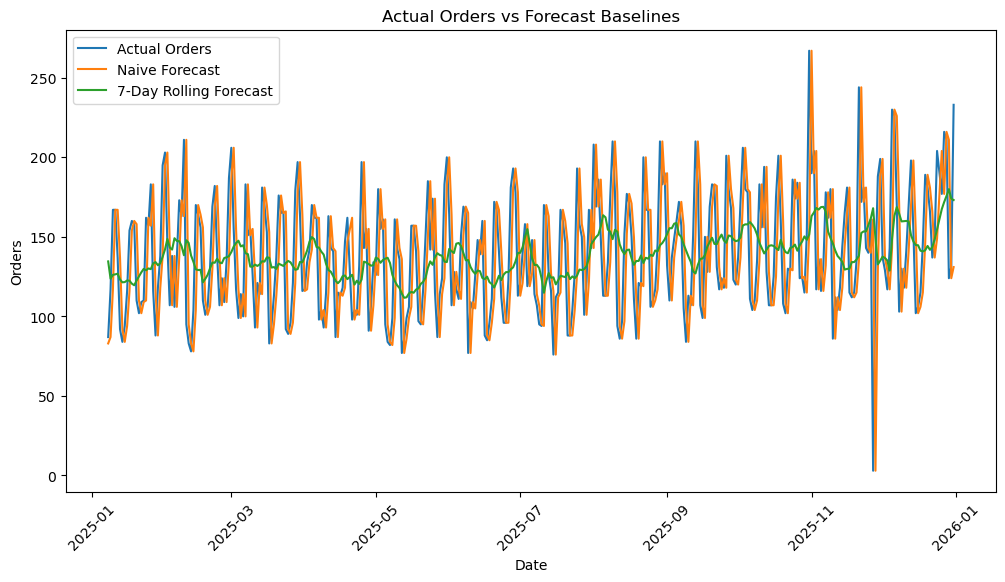

In [30]:
plt.figure(figsize=(12,6))
plt.plot(forecast_df['order_date'], forecast_df['orders'], label='Actual Orders')
plt.plot(forecast_df['order_date'], forecast_df['naive_forecast'], label='Naive Forecast')
plt.plot(forecast_df['order_date'], forecast_df['rolling_7_forecast'], label='7-Day Rolling Forecast')

plt.title('Actual Orders vs Forecast Baselines')
plt.xlabel('Date')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.legend()

plt.show()

## 3.6 Calculate Forecast Error Metrics

- Evaluate forecast quality using mean absolute error
- Compare naive vs rolling forecast performance

In [31]:
naive_mae = (forecast_df['orders'] - forecast_df['naive_forecast']).abs().mean()
rolling_7_mae = (forecast_df['orders'] - forecast_df['rolling_7_forecast']).abs().mean()

print(f'Naive Forecast MAE: {naive_mae:.2f}')
print(f'7-Day Rolling Forecast MAE: {rolling_7_mae:.2f}')

Naive Forecast MAE: 29.41
7-Day Rolling Forecast MAE: 30.07


## 3.7 Identify Better Baseline Model

- Compare error metrics across baseline approaches
- Select the stronger short-term forecasting method

In [32]:
if rolling_7_mae < naive_mae:
    print('7-day rolling forecast performs better based on MAE.')
else:
    print('Naive forecast performs better based on MAE.')

Naive forecast performs better based on MAE.


## 3.8 Preview Forecasting Dataset

- Inspect final modeling dataset
- Confirm readiness for forecast interpretation and operational translation

In [33]:
forecast_df.head()

,order_date,orders,revenue,orders_7d_avg,revenue_7d_avg,naive_forecast,rolling_7_forecast
0,2025-01-08,87,2529.40,123.714286,3710.097143,83.0,134.571429
1,2025-01-09,117,3008.53,126.142857,3720.422857,87.0,123.714286
2,2025-01-10,167,4843.45,126.428571,3653.194286,117.0,126.142857
3,2025-01-11,167,5333.94,126.857143,3687.188571,167.0,126.428571
4,2025-01-12,137,4667.45,123.142857,3685.492857,167.0,126.857143


# 4. Operational Forecasting & Business Translation

- Translate forecast outputs into operational decisions
- Use demand patterns to guide staffing, inventory, and peak planning
- Focus on actionable insights rather than model complexity
- Bridge data science output with real business impact

## 4.1 Forecast Next-Day Demand

- Use naive forecast as primary model
- Estimate next-day demand using the most recent observed value

In [47]:
latest_orders = forecast_df['orders'].iloc[-1]

next_day_forecast = latest_orders

next_day_forecast

233

## 4.2 Forecast Short-Term Demand (7-Day Outlook)

- Extend naive forecast across the next 7 days
- Create a forward-looking planning window

In [83]:
last_date = forecast_df['order_date'].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7
)

future_forecast = pd.DataFrame({
    'order_date': future_dates,
    'forecast_orders': next_day_forecast
})

future_forecast

,order_date,forecast_orders
0,2026-01-01,233
1,2026-01-02,233
2,2026-01-03,233
3,2026-01-04,233
4,2026-01-05,233
5,2026-01-06,233
6,2026-01-07,233


## 4.3 Staffing Planning Framework

- Translate forecasted demand into staffing requirements
- Use a simple orders-per-staff assumption

In [84]:
orders_per_staff = 30

future_forecast['required_staff'] = (
    future_forecast['forecast_orders'] / orders_per_staff
).round(0)

future_forecast

,order_date,forecast_orders,required_staff
0,2026-01-01,233,8.0
1,2026-01-02,233,8.0
2,2026-01-03,233,8.0
3,2026-01-04,233,8.0
4,2026-01-05,233,8.0
5,2026-01-06,233,8.0
6,2026-01-07,233,8.0


### 4.3.1 Allocate Staff by Role

- Split staffing into kitchen and front-of-house roles
- Use a 70/30 allocation between cooks and cashiers
- Apply minimum staffing constraints

In [85]:
future_forecast['cooks'] = (future_forecast['required_staff'] * 0.7).round(0)
future_forecast['cashiers'] = (future_forecast['required_staff'] * 0.3).round(0)

future_forecast['cooks'] = future_forecast['cooks'].clip(lower=1)
future_forecast['cashiers'] = future_forecast['cashiers'].clip(lower=1)

future_forecast

,order_date,forecast_orders,required_staff,cooks,cashiers
0,2026-01-01,233,8.0,6.0,2.0
1,2026-01-02,233,8.0,6.0,2.0
2,2026-01-03,233,8.0,6.0,2.0
3,2026-01-04,233,8.0,6.0,2.0
4,2026-01-05,233,8.0,6.0,2.0
5,2026-01-06,233,8.0,6.0,2.0
6,2026-01-07,233,8.0,6.0,2.0


### 4.3.2 Prepare Time-Based Features

- Rebuild time-based fields from the original order-level dataset
- Create weekday and hour features for hour-level staffing analysis

In [86]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

if 'order_datetime' not in df.columns:
    df['order_datetime'] = pd.to_datetime(df['order_date'], utc=True)
    df['order_datetime'] = df['order_datetime'].dt.tz_convert('America/Los_Angeles')

if 'order_date_clean' not in df.columns:
    df['order_date_clean'] = df['order_datetime'].dt.floor('D').dt.tz_localize(None)

df['order_dow'] = df['order_datetime'].dt.day_name()
df['order_hour'] = df['order_datetime'].dt.hour

df[['order_datetime', 'order_date_clean', 'order_dow', 'order_hour']].head()

,order_datetime,order_date_clean,order_dow,order_hour
0,2025-03-31 22:54:00-07:00,2025-03-31,Monday,22
1,2025-03-31 22:35:00-07:00,2025-03-31,Monday,22
2,2025-03-31 22:33:00-07:00,2025-03-31,Monday,22
3,2025-03-31 22:24:00-07:00,2025-03-31,Monday,22
4,2025-03-31 22:23:00-07:00,2025-03-31,Monday,22


### 4.3.3 Build Hour-Level Demand Base

- Aggregate orders at the date-hour level
- Preserve hourly demand before averaging across weekdays

In [87]:
hourly_base = (
    df.groupby(['order_date_clean', 'order_hour'])
      .agg(
          orders=('order_total', 'size')
      )
      .reset_index()
)

hourly_base.head()

,order_date_clean,order_hour,orders
0,2025-01-01,11,5
1,2025-01-01,12,8
2,2025-01-01,13,9
3,2025-01-01,14,9
4,2025-01-01,15,16


### 4.3.4 Compute Average Hourly Demand Profile

- Average hourly demand across matching weekday-hour combinations
- Create a reusable staffing baseline by weekday and hour

In [89]:
hourly_base['order_dow'] = hourly_base['order_date_clean'].dt.day_name()

hourly_demand = (
    hourly_base.groupby(['order_dow', 'order_hour'])
               .agg(
                   avg_orders=('orders', 'mean')
               )
               .reset_index()
)

hourly_demand.head()

,order_dow,order_hour,avg_orders
0,Friday,9,1.000000
1,Friday,10,1.882353
2,Friday,11,9.269231
3,Friday,12,8.826923
4,Friday,13,8.557692


### 4.3.5 Estimate Hour-Level Staffing Need

- Convert average hourly demand into staffing requirements
- Use an orders-per-staff-per-hour assumption

In [90]:
orders_per_staff_per_hour = 5

hourly_demand['required_staff'] = (
    hourly_demand['avg_orders'] / orders_per_staff_per_hour
).round(0)

hourly_demand['required_staff'] = hourly_demand['required_staff'].clip(lower=1)

hourly_demand.head()

,order_dow,order_hour,avg_orders,required_staff
0,Friday,9,1.000000,1.0
1,Friday,10,1.882353,1.0
2,Friday,11,9.269231,2.0
3,Friday,12,8.826923,2.0
4,Friday,13,8.557692,2.0


### 4.3.6 Allocate Hour-Level Roles

- Split hourly staffing into cooks and cashiers
- Apply the same 70/30 role allocation with minimum coverage

In [79]:
hourly_demand['cooks'] = (hourly_demand['required_staff'] * 0.7).round(0)
hourly_demand['cashiers'] = (hourly_demand['required_staff'] * 0.3).round(0)

hourly_demand['cooks'] = hourly_demand['cooks'].clip(lower=1)
hourly_demand['cashiers'] = hourly_demand['cashiers'].clip(lower=1)

hourly_demand.head()

,order_dow,order_hour,avg_orders,required_staff,cooks,cashiers
0,Monday,10,1.277778,1.0,1.0,1.0
1,Monday,11,5.884615,1.0,1.0,1.0
2,Monday,12,5.423077,1.0,1.0,1.0
3,Monday,13,6.596154,1.0,1.0,1.0
4,Monday,14,6.615385,1.0,1.0,1.0


### 4.3.7 Sort Hour-Level Staffing Table

- Organize staffing output by weekday and hour
- Prepare the table for operational review

In [80]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

hourly_demand['order_dow'] = pd.Categorical(
    hourly_demand['order_dow'],
    categories=dow_order,
    ordered=True
)

hourly_demand = hourly_demand.sort_values(['order_dow', 'order_hour']).reset_index(drop=True)

hourly_demand.head(20)

,order_dow,order_hour,avg_orders,required_staff,cooks,cashiers
0,Monday,10,1.277778,1.0,1.0,1.0
1,Monday,11,5.884615,1.0,1.0,1.0
2,Monday,12,5.423077,1.0,1.0,1.0
3,Monday,13,6.596154,1.0,1.0,1.0
4,Monday,14,6.615385,1.0,1.0,1.0
5,Monday,15,8.519231,2.0,1.0,1.0
6,Monday,16,12.230769,2.0,1.0,1.0
7,Monday,17,13.750000,3.0,2.0,1.0
8,Monday,18,13.730769,3.0,2.0,1.0
9,Monday,19,11.769231,2.0,1.0,1.0


### 4.3.8 Create Hour-Level Staffing Pivot Table

- Reshape staffing requirements into a weekday-by-hour format
- Improve readability for operational review

In [92]:
pivot_table = hourly_demand.pivot(
    index='order_hour',
    columns='order_dow',
    values='required_staff'
)

pivot_table

order_dow,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
order_hour,,,,,,,
9,1.0,NaN,1.0,NaN,NaN,NaN,1.0
10,1.0,1.0,1.0,1.0,1.0,1.0,1.0
11,2.0,1.0,1.0,2.0,1.0,1.0,1.0
12,2.0,1.0,2.0,2.0,1.0,1.0,1.0
13,2.0,1.0,2.0,2.0,2.0,1.0,1.0
14,2.0,1.0,2.0,3.0,2.0,2.0,1.0
15,3.0,2.0,3.0,3.0,2.0,2.0,2.0
16,4.0,2.0,4.0,4.0,3.0,2.0,3.0
17,5.0,3.0,4.0,4.0,3.0,3.0,3.0


### 4.3.9 Plot Hour-Level Staffing Requirement

- Visualize staffing need by hour and weekday
- Identify peak labor windows

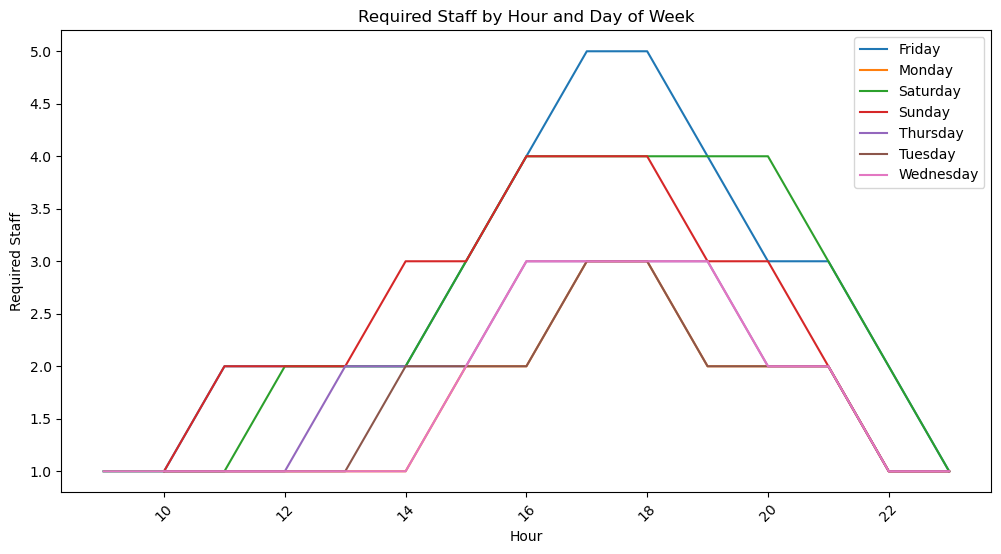

In [93]:
pivot_staff = hourly_demand.pivot(
    index='order_hour',
    columns='order_dow',
    values='required_staff'
)

plt.figure(figsize=(12, 6))

for col in pivot_staff.columns:
    plt.plot(pivot_staff.index, pivot_staff[col], label=col)

plt.title('Required Staff by Hour and Day of Week')
plt.xlabel('Hour')
plt.ylabel('Required Staff')
plt.xticks(rotation=45)
plt.legend()

plt.show()

### 4.3.10 Final Hour-Level Staffing Output

- Review staffing needs by weekday, hour, and role
- Produce a shift-planning output for operations

In [94]:
hourly_demand

,order_dow,order_hour,avg_orders,required_staff
0,Friday,9,1.000000,1.0
1,Friday,10,1.882353,1.0
2,Friday,11,9.269231,2.0
3,Friday,12,8.826923,2.0
4,Friday,13,8.557692,2.0
...,...,...,...,...
96,Wednesday,19,12.886792,3.0
97,Wednesday,20,10.905660,2.0
98,Wednesday,21,9.283019,2.0
99,Wednesday,22,6.019231,1.0


## 4.4 Identify Peak Demand Thresholds

- Define high-demand days using the historical order distribution

In [95]:
peak_threshold = forecast_df['orders'].quantile(0.8)

peak_threshold

172.0

## 4.5 Flag High-Demand Days

- Identify which forecasted days exceed the peak threshold
- Highlight forecast periods that may require extra preparation

In [96]:
future_forecast['is_peak_day'] = future_forecast['forecast_orders'] >= peak_threshold

future_forecast

,order_date,forecast_orders,required_staff,cooks,cashiers,is_peak_day
0,2026-01-01,233,8.0,6.0,2.0,True
1,2026-01-02,233,8.0,6.0,2.0,True
2,2026-01-03,233,8.0,6.0,2.0,True
3,2026-01-04,233,8.0,6.0,2.0,True
4,2026-01-05,233,8.0,6.0,2.0,True
5,2026-01-06,233,8.0,6.0,2.0,True
6,2026-01-07,233,8.0,6.0,2.0,True


## 4.6 Inventory Planning Signal

- Translate demand into relative inventory requirements
- Compare forecasted demand against the historical average

In [97]:
avg_orders = forecast_df['orders'].mean()

future_forecast['vs_avg_demand'] = future_forecast['forecast_orders'] / avg_orders

future_forecast

,order_date,forecast_orders,required_staff,cooks,cashiers,is_peak_day,vs_avg_demand
0,2026-01-01,233,8.0,6.0,2.0,True,1.674195
1,2026-01-02,233,8.0,6.0,2.0,True,1.674195
2,2026-01-03,233,8.0,6.0,2.0,True,1.674195
3,2026-01-04,233,8.0,6.0,2.0,True,1.674195
4,2026-01-05,233,8.0,6.0,2.0,True,1.674195
5,2026-01-06,233,8.0,6.0,2.0,True,1.674195
6,2026-01-07,233,8.0,6.0,2.0,True,1.674195


## 4.7 Final Operational Forecast Table

- Combine forecast, staffing, and demand signals
- Produce a decision-ready operations table

In [98]:
future_forecast

,order_date,forecast_orders,required_staff,cooks,cashiers,is_peak_day,vs_avg_demand
0,2026-01-01,233,8.0,6.0,2.0,True,1.674195
1,2026-01-02,233,8.0,6.0,2.0,True,1.674195
2,2026-01-03,233,8.0,6.0,2.0,True,1.674195
3,2026-01-04,233,8.0,6.0,2.0,True,1.674195
4,2026-01-05,233,8.0,6.0,2.0,True,1.674195
5,2026-01-06,233,8.0,6.0,2.0,True,1.674195
6,2026-01-07,233,8.0,6.0,2.0,True,1.674195
